# Домашнее задание №5–6: baseline ML-модуля для Hypothesa

**Задача:** классификация тональности короткого русскоязычного сообщения
пользователя: `negative / neutral / positive`.

**Зачем это Hypothesa:** основной продукт собирает открытые ответы, выделяет темы и
перестраивает опрос. Классификатор тональности — вспомогательный ML-модуль, который:

1. проверяет, соответствует ли ответ вопросу «что нравится / что не нравится»;
2. позволяет считать рейтинг темы отдельно для позитивных и негативных упоминаний;
3. отправляет нейтральные или неуверенные ответы на уточнение/ручную проверку.

Исходных данных Hypothesa пока недостаточно для честного supervised baseline:
в прототипе 25 интервью, после очистки около 15 информативных ответов и нет ручных
меток. Поэтому здесь используется **публичный proxy-корпус SentiRuEval-2016**:
русскоязычные сообщения о банках и телеком-компаниях с тремя метками тональности.
Это не выдаётся за финальную production-оценку: перенос на ответы Hypothesa отдельно
обсуждается в ограничениях.

Источники:

- [карточка набора данных на Hugging Face](https://huggingface.co/datasets/mteb/SentiRuEval2016)
- [репозиторий и исходные данные SentiRuEval-2016](https://github.com/mokoron/sentirueval)
- Loukachevitch N. V., Rubtsova Y. V. (2016), *SentiRuEval-2016: overcoming time gap and data sparsity in tweet sentiment analysis*.

## 0. Проверяемая гипотеза и схема эксперимента

**ML-постановка:** многоклассовая классификация текста.

- Объект: одно короткое сообщение пользователя.
- Признаки: текст сообщения после минимальной нормализации.
- Target: `-1` — negative, `0` — neutral, `1` — positive.
- Primary metric: **Macro-F1**, потому что ошибки по каждому классу одинаково важны.
- Дополнительные метрики: Accuracy, Balanced Accuracy, Top-2 Accuracy.
- Совокупная метрика: `Q = 0.7 × Macro-F1 + 0.3 × Accuracy`.
- Split: официальный test не участвует ни в подборе параметров, ни в выборе порога.
  Для Optuna из очищенного train выделяется стратифицированный validation.

**Гипотеза:** объединение word- и character-TF-IDF и подбор гиперпараметров даст
Macro-F1 выше простых word-TF-IDF baseline-моделей. Character n-граммы должны помочь
с опечатками, словоформами, хештегами и разговорным русским текстом.

In [1]:
from __future__ import annotations

import importlib.util
import random
import re
import subprocess
import sys
import time
import warnings

# В Colab обычно уже есть основной scientific stack, но Optuna/pyarrow могут отсутствовать.
missing_packages = [
    package
    for package, module in [("optuna>=3.6,<5", "optuna"), ("pyarrow>=15", "pyarrow")]
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *missing_packages],
        check=True,
    )

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import sparse
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    top_k_accuracy_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 140)

LABELS = np.array([-1, 0, 1])
LABEL_NAMES = {-1: "negative", 0: "neutral", 1: "positive"}
DATA_BASE = "https://huggingface.co/datasets/mteb/SentiRuEval2016/resolve/main/data/"

print("Версии:")
print("pandas:", pd.__version__)
print("scikit-learn импортирован успешно")
print("optuna:", optuna.__version__)

C:\Users\herog\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Версии:
pandas: 2.3.3
scikit-learn импортирован успешно
optuna: 4.6.0


## 1. Загрузка и первичный аудит данных — 4 балла

Parquet-файлы читаются напрямую из публичного репозитория. Локальная ручная правка
исходных файлов не нужна, поэтому ноутбук воспроизводится с чистого окружения.

In [2]:
train_raw = pd.read_parquet(DATA_BASE + "train-00000-of-00001.parquet")
test_raw = pd.read_parquet(DATA_BASE + "test-00000-of-00001.parquet")

display(train_raw.head())
print("train:", train_raw.shape, "test:", test_raw.shape)
print("columns:", train_raw.dtypes.to_dict())

assert list(train_raw.columns) == ["text", "label"]
assert set(train_raw["label"].unique()) == set(LABELS)
assert set(test_raw["label"].unique()) == set(LABELS)

,text,label
0,Блядский пидорский билайн. извините но нет сил,-1
1,Почему МТС в Дагестане не работает? Кто знает?,-1
2,"у меня теле2 уже больше 10 лет, так что можешь мне не рассказывать:) в школьном гардеробе он не принимает совсем, а в бассейне плохо.",-1
3,RT @Sloviansk: #МТС и #Киевстар лежит по всей Донецкой области,-1
4,И этот пчелайн интернет. Он вроде есть. Но его нет.,-1


train: (3000, 2) test: (3000, 2)
columns: {'text': dtype('O'), 'label': dtype('int64')}


In [3]:
URL_RE = re.compile(r"(?:https?://|www\.)\S+", flags=re.IGNORECASE)
USER_RE = re.compile(r"(?<!\w)@\w+", flags=re.UNICODE)
SPACE_RE = re.compile(r"\s+")


def clean_text(text: str) -> str:
    """Минимальная нормализация без потери отрицаний и эмоциональных маркеров."""
    text = URL_RE.sub(" URL ", str(text))
    text = USER_RE.sub(" USER ", text)
    return SPACE_RE.sub(" ", text).strip()


def add_clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["clean_text"] = result["text"].map(clean_text)
    result["key"] = result["clean_text"].str.casefold()
    return result


train = add_clean_columns(train_raw)
test = add_clean_columns(test_raw)


def split_audit(name: str, df: pd.DataFrame) -> dict[str, int | str]:
    group_label_counts = df.groupby("key")["label"].nunique()
    conflict_keys = set(group_label_counts[group_label_counts > 1].index)
    return {
        "split": name,
        "rows": len(df),
        "missing_text": int(df["text"].isna().sum()),
        "empty_after_clean": int(df["clean_text"].eq("").sum()),
        "exact_duplicate_rows": int(df["text"].duplicated().sum()),
        "normalized_duplicate_rows": int(df["key"].duplicated().sum()),
        "conflicting_duplicate_keys": len(conflict_keys),
        "rows_with_conflicting_label": int(df["key"].isin(conflict_keys).sum()),
    }


audit = pd.DataFrame([split_audit("train", train), split_audit("test", test)])
cross_split_keys = set(train["key"]) & set(test["key"])
display(audit)
print("Нормализованных текстов одновременно в train и test:", len(cross_split_keys))
print("Строк train с пересечением:", int(train["key"].isin(cross_split_keys).sum()))
print("Строк test с пересечением:", int(test["key"].isin(cross_split_keys).sum()))

,split,rows,missing_text,empty_after_clean,exact_duplicate_rows,normalized_duplicate_rows,conflicting_duplicate_keys,rows_with_conflicting_label
0,train,3000,0,0,98,148,8,16
1,test,3000,0,0,78,141,10,20


Нормализованных текстов одновременно в train и test: 209
Строк train с пересечением: 260
Строк test с пересечением: 253


### Решения по очистке

1. URL и `@username` заменяем стабильными токенами `URL` и `USER`: конкретный адрес
   или пользователь не должен определять тональность; это также уменьшает PII.
2. Схлопываем пробелы и переносы строк.
3. **Не** удаляем стоп-слова, пунктуацию, эмодзи и отрицания: «не работает» нельзя
   превращать в «работает».
4. Из train удаляем тексты с конфликтующими метками: для одинакового объекта target
   неоднозначен.
5. Из train удаляем все нормализованные тексты, встречающиеся в test. Иначе оценка
   будет завышена утечкой.
6. Оставшиеся повторы train с одинаковой меткой сворачиваем до одной строки.
7. Официальный test не меняем для основной оценки. Отдельно ниже считаем метрики на
   deduplicated test как sensitivity check.

In [4]:
train_label_nunique = train.groupby("key")["label"].nunique()
train_conflict_keys = set(train_label_nunique[train_label_nunique > 1].index)

train_clean = (
    train.loc[
        ~train["key"].isin(train_conflict_keys)
        & ~train["key"].isin(cross_split_keys)
        & train["clean_text"].ne("")
    ]
    .drop_duplicates(subset="key", keep="first")
    .reset_index(drop=True)
)
test_official = test.copy().reset_index(drop=True)

assert set(train_clean["key"]).isdisjoint(set(test_official["key"]))
assert train_clean.groupby("key")["label"].nunique().max() == 1
assert train_clean["clean_text"].ne("").all()

cleaning_report = pd.DataFrame(
    {
        "stage": ["raw train", "leakage-safe train", "official test"],
        "rows": [len(train_raw), len(train_clean), len(test_official)],
        "negative": [
            int((train_raw.label == -1).sum()),
            int((train_clean.label == -1).sum()),
            int((test_official.label == -1).sum()),
        ],
        "neutral": [
            int((train_raw.label == 0).sum()),
            int((train_clean.label == 0).sum()),
            int((test_official.label == 0).sum()),
        ],
        "positive": [
            int((train_raw.label == 1).sum()),
            int((train_clean.label == 1).sum()),
            int((test_official.label == 1).sum()),
        ],
    }
)
display(cleaning_report)
print(f"После очистки осталось {len(train_clean) / len(train_raw):.1%} исходного train.")

,stage,rows,negative,neutral,positive
0,raw train,3000,1000,1000,1000
1,leakage-safe train,2636,804,956,876
2,official test,3000,1000,1000,1000


После очистки осталось 87.9% исходного train.


## 2. Анализ данных — 5 баллов

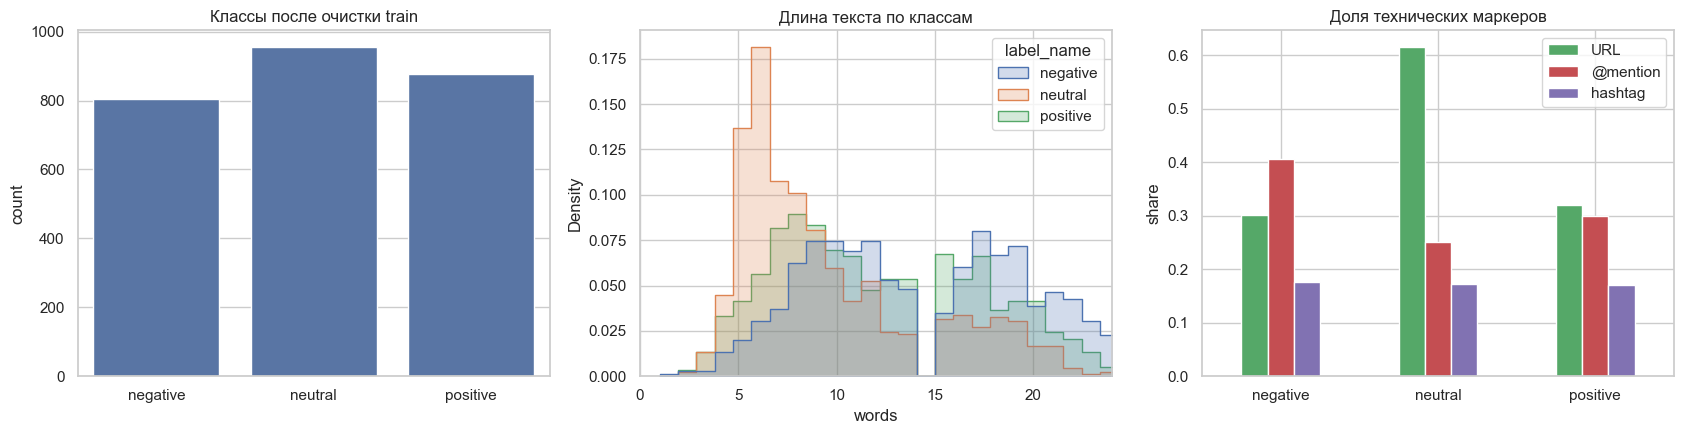

words                  chars                  
           count median  mean max count median  mean  max
label_name                                               
negative     804   14.0  14.2  27   804   89.0  90.2  152
neutral      956    8.0   9.6  29   956   52.0  63.3  155
positive     876   11.0  12.2  28   876   77.0  82.6  148

,URL,@mention,hashtag
label,,,
negative,0.301,0.407,0.177
neutral,0.616,0.251,0.173
positive,0.321,0.299,0.171


In [5]:
for frame in (train_clean, test_official):
    frame["label_name"] = frame["label"].map(LABEL_NAMES)
    frame["chars"] = frame["clean_text"].str.len()
    frame["words"] = frame["clean_text"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(
    data=train_clean,
    x="label_name",
    order=["negative", "neutral", "positive"],
    ax=axes[0],
    color="#4C72B0",
)
axes[0].set_title("Классы после очистки train")
axes[0].set_xlabel("")

sns.histplot(
    data=train_clean,
    x="words",
    hue="label_name",
    hue_order=["negative", "neutral", "positive"],
    bins=30,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_xlim(0, train_clean["words"].quantile(0.99))
axes[1].set_title("Длина текста по классам")

eda_markers = pd.DataFrame(
    {
        "URL": train_raw["text"].str.contains(r"https?://|www\.", case=False, regex=True).groupby(train_raw.label).mean(),
        "@mention": train_raw["text"].str.contains(r"@\w+", regex=True).groupby(train_raw.label).mean(),
        "hashtag": train_raw["text"].str.contains("#", regex=False).groupby(train_raw.label).mean(),
    }
).rename(index=LABEL_NAMES)
eda_markers.plot(kind="bar", ax=axes[2], color=["#55A868", "#C44E52", "#8172B2"])
axes[2].set_title("Доля технических маркеров")
axes[2].set_xlabel("")
axes[2].set_ylabel("share")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

length_summary = (
    train_clean.groupby("label_name")[["words", "chars"]]
    .agg(["count", "median", "mean", "max"])
    .round(1)
)
display(length_summary)
display(eda_markers.round(3))

In [6]:
print("Случайные примеры каждого класса:")
examples = (
    train_clean.groupby("label_name", group_keys=False)
    .sample(n=3, random_state=SEED)[["label_name", "clean_text"]]
    .sort_values("label_name")
)
display(examples)

Случайные примеры каждого класса:


,label_name,clean_text
192,negative,USER сначала пытался через онлайн-чат у вас на сайте. Никто не ответил. Потом через форму обратной связи.
717,negative,"коммент к новости о МТС - ""все ваше оборуд.уже давно распродали на янгиабаде. придется все строить заново""..."
168,negative,"21 июля. FINMARKET.RU - Рост неопределенности и недоверия, вызванный новым раундом санкций США в отношении ВЭБа, Газпромбанка, ""Роснефти"" и"
846,neutral,"USER , сбербанк кредиты индивидуальным предпринимателям URL"
1200,neutral,где оплатить кредит альфа банка URL
1596,neutral,"В ходе акции ""Ленточка Ленинградской победы"" ленты будут раздавать в школах, отделениях Сбербанка и почты."
2305,positive,"Думаю,что так у всех операторов. Интернет-помощник у МТС неплохой,в отличии от никакого билайновского. Пользуюсь МТС и Билайн."
2136,positive,В МТС работают красавчики:D
2529,positive,НОВОСТИ КОМПАНИЙ. Газпромбанк продолжает стабильно работать: Введённые Европейским союзом в отношении ряда рос... URL


### Выводы EDA

- Исходные splits сбалансированы, но после leakage-safe очистки train становится
  умеренно несбалансированным — поэтому кроме Accuracy нужна Macro-F1.
- Тексты короткие и разговорные; встречаются опечатки, словоформы, хештеги и
  эмоциональная пунктуация. Это аргумент в пользу character n-грамм.
- URL и mentions распределены по классам неравномерно и могут стать shortcut-
  признаками. Маскирование сохраняет факт их наличия, но не конкретную сущность.
- Neutral семантически сложен: новость о проблеме может содержать негативные слова,
  но не выражать отношение автора. Этого bag-of-ngrams часто недостаточно — ожидаем
  основные ошибки между neutral и двумя полярными классами.

## 3. Модели — 7 баллов

Сравниваем:

0. `DummyClassifier` — sanity check, не считаем полноценной ML-моделью.
1. **ComplementNB + word TF-IDF** — простой быстрый baseline для разреженного текста.
2. **LinearSVC + word TF-IDF** — сильный линейный baseline.
3. **LinearSVC + early fusion word/character TF-IDF + Optuna** — усложнённая модель.

Векторизаторы всегда обучаются только на train. Test используется ровно для финальной
оценки моделей, но не для настройки сложной модели.

## 4. Метрики и совокупная оценка — 4 балла

- **Macro-F1** — primary: усредняет F1 трёх классов без веса размера класса.
- **Accuracy** — понятная продуктовая доля правильно маршрутизированных сообщений.
- **Balanced Accuracy** — средняя полнота классов; проверяет влияние дисбаланса.
- **Top-2 Accuracy** — доля случаев, где правильный класс входит в два наиболее
  вероятных. Полезна для сценария «модель предлагает аналитику два варианта».
- **Q = 0.7 × Macro-F1 + 0.3 × Accuracy** — интегральная метрика. Macro-F1 получает
  больший вес, чтобы хороший результат на neutral не был принесён в жертву общей
  доле правильных ответов.

In [7]:
X_train_full = train_clean["clean_text"]
y_train_full = train_clean["label"]
X_test = test_official["clean_text"]
y_test = test_official["label"].to_numpy()

model_rows: list[dict[str, float | str]] = []
predictions: dict[str, np.ndarray] = {}
decision_scores: dict[str, np.ndarray] = {}


def evaluate_estimator(name: str, estimator: Pipeline) -> None:
    started = time.perf_counter()
    estimator.fit(X_train_full, y_train_full)
    fit_seconds = time.perf_counter() - started

    started = time.perf_counter()
    pred = estimator.predict(X_test)
    predict_seconds = time.perf_counter() - started

    if hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X_test)
    else:
        scores = estimator.predict_proba(X_test)

    accuracy = accuracy_score(y_test, pred)
    macro_f1 = f1_score(y_test, pred, average="macro")
    model_rows.append(
        {
            "model": name,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "balanced_accuracy": balanced_accuracy_score(y_test, pred),
            "top2_accuracy": top_k_accuracy_score(
                y_test, scores, k=2, labels=estimator.classes_
            ),
            "Q": 0.7 * macro_f1 + 0.3 * accuracy,
            "fit_seconds": fit_seconds,
            "predict_ms_per_1000": predict_seconds / len(X_test) * 1_000_000,
        }
    )
    predictions[name] = np.asarray(pred)
    decision_scores[name] = np.asarray(scores)


dummy = Pipeline(
    [
        ("tfidf", TfidfVectorizer(min_df=2)),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED)),
    ]
)
cnb = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                sublinear_tf=True,
            ),
        ),
        ("model", ComplementNB(alpha=0.5)),
    ]
)
word_svc = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                sublinear_tf=True,
            ),
        ),
        ("model", LinearSVC(C=1.0, random_state=SEED)),
    ]
)

evaluate_estimator("Dummy (sanity check)", dummy)
evaluate_estimator("ComplementNB + word TF-IDF", cnb)
evaluate_estimator("LinearSVC + word TF-IDF", word_svc)

display(pd.DataFrame(model_rows).round(4))

,model,accuracy,macro_f1,balanced_accuracy,top2_accuracy,Q,fit_seconds,predict_ms_per_1000
0,Dummy (sanity check),0.3333,0.1667,0.3333,0.6667,0.2167,0.0155,4.4641
1,ComplementNB + word TF-IDF,0.7213,0.7202,0.7213,0.9093,0.7205,0.0294,7.3682
2,LinearSVC + word TF-IDF,0.7157,0.7153,0.7157,0.8997,0.7154,0.0344,7.4598


### Усложнённая модель: word + char early fusion и Optuna

Word TF-IDF хорошо ловит устойчивые слова и фразы, char TF-IDF — части слов,
опечатки и морфологию. Признаки конкатенируются до LinearSVC. На validation Optuna
подбирает:

- `C` — силу регуляризации LinearSVC;
- `char_weight` — относительный масштаб character-признаков;
- `class_weight` — нужна ли компенсация дисбаланса после очистки.

Число trials ограничено 30: этого достаточно для baseline и ноутбук остаётся быстрым.

Best validation Q: 0.7391
Best params: {'C': 0.053518346201881145, 'char_weight': 1.8897649189821968, 'class_weight': None}


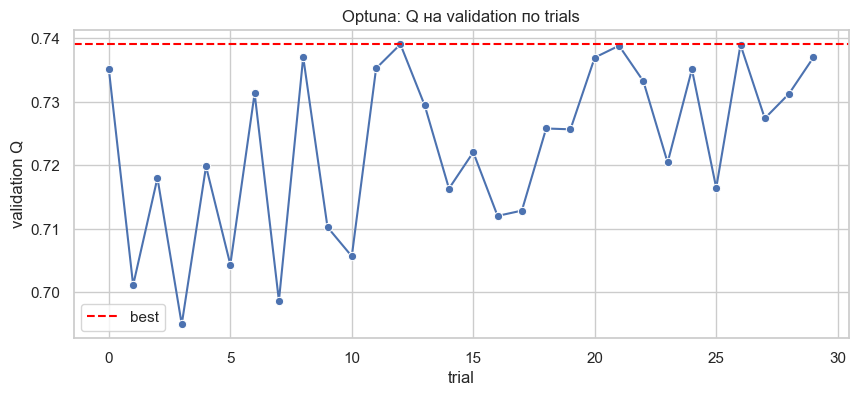

In [8]:
X_dev, X_val, y_dev, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=SEED,
)

word_vectorizer_dev = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=30_000,
)
char_vectorizer_dev = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
    max_features=50_000,
)

word_dev = word_vectorizer_dev.fit_transform(X_dev)
word_val = word_vectorizer_dev.transform(X_val)
char_dev = char_vectorizer_dev.fit_transform(X_dev)
char_val = char_vectorizer_dev.transform(X_val)


def fused(word_matrix, char_matrix, char_weight: float):
    return sparse.hstack(
        [word_matrix, char_matrix * char_weight],
        format="csr",
    )


def objective(trial: optuna.Trial) -> float:
    params = {
        "C": trial.suggest_float("C", 0.05, 5.0, log=True),
        "char_weight": trial.suggest_float("char_weight", 0.1, 2.0, log=True),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }
    model = LinearSVC(
        C=params["C"],
        class_weight=params["class_weight"],
        random_state=SEED,
    )
    model.fit(fused(word_dev, char_dev, params["char_weight"]), y_dev)
    pred = model.predict(fused(word_val, char_val, params["char_weight"]))
    macro_f1 = f1_score(y_val, pred, average="macro")
    accuracy = accuracy_score(y_val, pred)
    return 0.7 * macro_f1 + 0.3 * accuracy


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=30, show_progress_bar=False)

print("Best validation Q:", round(study.best_value, 4))
print("Best params:", study.best_params)

trial_frame = study.trials_dataframe(attrs=("number", "value", "params", "state"))
plt.figure(figsize=(10, 4))
sns.lineplot(data=trial_frame, x="number", y="value", marker="o")
plt.axhline(study.best_value, color="red", linestyle="--", label="best")
plt.title("Optuna: Q на validation по trials")
plt.xlabel("trial")
plt.ylabel("validation Q")
plt.legend()
plt.show()

In [9]:
best_params = study.best_params

# Порог отказа выбираем только на validation: отбрасываем 10% ответов с наименьшим margin.
dev_best_model = LinearSVC(
    C=best_params["C"],
    class_weight=best_params["class_weight"],
    random_state=SEED,
)
dev_best_model.fit(
    fused(word_dev, char_dev, best_params["char_weight"]),
    y_dev,
)
val_scores = dev_best_model.decision_function(
    fused(word_val, char_val, best_params["char_weight"])
)
val_sorted = np.sort(val_scores, axis=1)
val_margin = val_sorted[:, -1] - val_sorted[:, -2]
abstain_threshold = float(np.quantile(val_margin, 0.10))
print("Validation margin threshold for ~90% coverage:", round(abstain_threshold, 4))

# Финальное переобучение всех признаков на полном leakage-safe train.
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=30_000,
)
char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
    max_features=50_000,
)

started = time.perf_counter()
word_train = word_vectorizer.fit_transform(X_train_full)
word_test = word_vectorizer.transform(X_test)
char_train = char_vectorizer.fit_transform(X_train_full)
char_test = char_vectorizer.transform(X_test)

final_model = LinearSVC(
    C=best_params["C"],
    class_weight=best_params["class_weight"],
    random_state=SEED,
)
final_model.fit(
    fused(word_train, char_train, best_params["char_weight"]),
    y_train_full,
)
fit_seconds = time.perf_counter() - started

started = time.perf_counter()
final_test_features = fused(word_test, char_test, best_params["char_weight"])
final_pred = final_model.predict(final_test_features)
final_scores = final_model.decision_function(final_test_features)
predict_seconds = time.perf_counter() - started

final_accuracy = accuracy_score(y_test, final_pred)
final_macro_f1 = f1_score(y_test, final_pred, average="macro")
model_rows.append(
    {
        "model": "Tuned word+char LinearSVC",
        "accuracy": final_accuracy,
        "macro_f1": final_macro_f1,
        "balanced_accuracy": balanced_accuracy_score(y_test, final_pred),
        "top2_accuracy": top_k_accuracy_score(
            y_test, final_scores, k=2, labels=final_model.classes_
        ),
        "Q": 0.7 * final_macro_f1 + 0.3 * final_accuracy,
        "fit_seconds": fit_seconds,
        "predict_ms_per_1000": predict_seconds / len(X_test) * 1_000_000,
    }
)
predictions["Tuned word+char LinearSVC"] = final_pred
decision_scores["Tuned word+char LinearSVC"] = final_scores

comparison = pd.DataFrame(model_rows).sort_values("Q", ascending=False).reset_index(drop=True)
display(
    comparison.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "top2_accuracy": "{:.4f}",
            "Q": "{:.4f}",
            "fit_seconds": "{:.3f}",
            "predict_ms_per_1000": "{:.2f}",
        }
    ).highlight_max(subset=["accuracy", "macro_f1", "balanced_accuracy", "top2_accuracy", "Q"], color="#c6efce")
)

Validation margin threshold for ~90% coverage: 0.0954


,model,accuracy,macro_f1,balanced_accuracy,top2_accuracy,Q,fit_seconds,predict_ms_per_1000
0,Tuned word+char LinearSVC,0.7563,0.7559,0.7563,0.9240,0.7560,0.365,1.92
1,ComplementNB + word TF-IDF,0.7213,0.7202,0.7213,0.9093,0.7205,0.029,7.37
2,LinearSVC + word TF-IDF,0.7157,0.7153,0.7157,0.8997,0.7154,0.034,7.46
3,Dummy (sanity check),0.3333,0.1667,0.3333,0.6667,0.2167,0.016,4.46


## 5. Анализ ошибок и постобработка предсказаний

,precision,recall,f1-score,support
negative,0.7636,0.8170,0.7894,1000.0000
neutral,0.7767,0.7340,0.7548,1000.0000
positive,0.7289,0.7180,0.7234,1000.0000
accuracy,0.7563,0.7563,0.7563,0.7563
macro avg,0.7564,0.7563,0.7559,3000.0000
weighted avg,0.7564,0.7563,0.7559,3000.0000


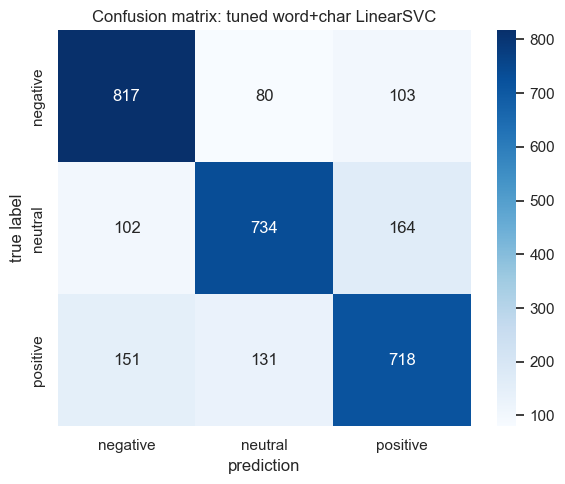

In [10]:
report = pd.DataFrame(
    classification_report(
        y_test,
        final_pred,
        labels=LABELS,
        target_names=[LABEL_NAMES[x] for x in LABELS],
        output_dict=True,
        zero_division=0,
    )
).T
display(report.round(4))

cm = confusion_matrix(y_test, final_pred, labels=LABELS)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[LABEL_NAMES[x] for x in LABELS],
    yticklabels=[LABEL_NAMES[x] for x in LABELS],
)
plt.title("Confusion matrix: tuned word+char LinearSVC")
plt.xlabel("prediction")
plt.ylabel("true label")
plt.tight_layout()
plt.show()

In [11]:
score_order = np.sort(final_scores, axis=1)
test_margin = score_order[:, -1] - score_order[:, -2]

error_frame = test_official[["text", "clean_text", "label", "words"]].copy()
error_frame["prediction"] = final_pred
error_frame["true_name"] = error_frame["label"].map(LABEL_NAMES)
error_frame["pred_name"] = error_frame["prediction"].map(LABEL_NAMES)
error_frame["margin"] = test_margin
error_frame["correct"] = error_frame["label"].eq(error_frame["prediction"])

print("Уверенные ошибки — самые полезные кандидаты для ручной проверки:")
display(
    error_frame.loc[~error_frame["correct"]]
    .sort_values("margin", ascending=False)[["text", "true_name", "pred_name", "margin"]]
    .head(12)
)

Уверенные ошибки — самые полезные кандидаты для ручной проверки:


,text,true_name,pred_name,margin
2724,http://t.co/U4kM2kVArB втб 24 кредиты онлайн,positive,neutral,2.635871
1973,@MegaFonHelp спасибо,neutral,positive,2.351407
1857,"Санкции против Банка Москвы, ВТБ и Россельхозбанка не коснулись транзакций",neutral,negative,2.191635
2616,RT @EchoMskNews: ЕС не намерен вносить Сбербанк и ВТБ в свой санкционный список http://t.co/PGG6S4wBYe,positive,negative,1.903951
1134,"#МТС #Украина обратилась к другим украинским операторам,чтобы восстановить связь в Крыму http://t.co/Ks7uZoB9Sc\n#санкции #Крым #ДНР #СШ...",neutral,negative,1.869373
2961,заморозили кредит сбербанк россий http://t.co/PitVGgdJcV,positive,neutral,1.662188
1272,"#RETWEET Москва, 6 августа. ""МТС Украина"", сеть которой перестала работать в Крыму в ночь на среду, обратилась к украинским оператора...",neutral,negative,1.593523
2218,"ЕС не намерен вносить Сбербанк и ВТБ в свой санкционный список http://t.co/LUuoy4qPM7\nПерекреститесь, вас пока пожалели. Приберегли на ...",positive,negative,1.587204
1299,"RT @Pjatak: Если санкции против Сбер и ВТБ, то всё, капец Макдональдсу!",neutral,negative,1.570453
2471,Автокредит сбербанк без справки о доходах http://t.co/APieH7LZAJ,positive,neutral,1.543842


,length_bucket,samples,accuracy,median_margin
0,1–5,285,0.8421,0.9896
1,6–10,1086,0.8002,0.8619
2,11–20,1400,0.7200,0.5894
3,21+,229,0.6638,0.4699


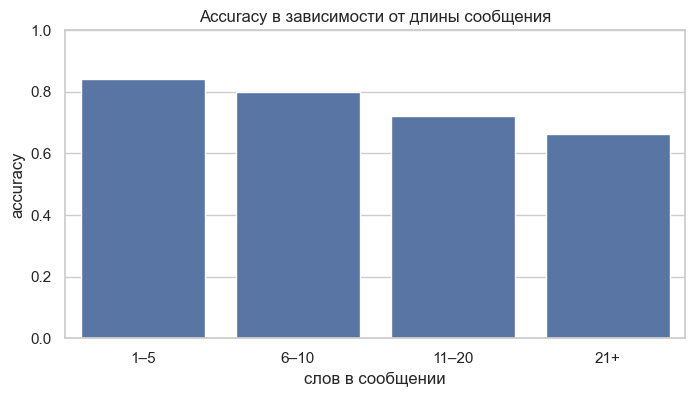

In [12]:
error_frame["length_bucket"] = pd.cut(
    error_frame["words"],
    bins=[0, 5, 10, 20, np.inf],
    labels=["1–5", "6–10", "11–20", "21+"],
)
length_quality = (
    error_frame.groupby("length_bucket", observed=True)
    .agg(samples=("correct", "size"), accuracy=("correct", "mean"), median_margin=("margin", "median"))
    .reset_index()
)
display(length_quality.round(4))

plt.figure(figsize=(8, 4))
sns.barplot(data=length_quality, x="length_bucket", y="accuracy", color="#4C72B0")
plt.ylim(0, 1)
plt.title("Accuracy в зависимости от длины сообщения")
plt.xlabel("слов в сообщении")
plt.ylabel("accuracy")
plt.show()

### Sensitivity check: дубли test и статистическая неопределённость

Основная таблица использует официальный test. Но в нём есть дубли и конфликтующие
дубли, поэтому дополнительно:

1. удаляем из копии test конфликтующие нормализованные тексты;
2. оставляем один экземпляр каждого текста;
3. считаем метрики повторно;
4. строим paired bootstrap 95% CI для выигрыша Accuracy сложной модели над лучшим
   простым baseline на официальном test.

In [13]:
test_label_nunique = test_official.groupby("key")["label"].nunique()
test_conflict_keys = set(test_label_nunique[test_label_nunique > 1].index)
test_unique = (
    test_official.loc[~test_official["key"].isin(test_conflict_keys)]
    .drop_duplicates("key")
    .reset_index(drop=True)
)

word_unique = word_vectorizer.transform(test_unique["clean_text"])
char_unique = char_vectorizer.transform(test_unique["clean_text"])
unique_pred = final_model.predict(
    fused(word_unique, char_unique, best_params["char_weight"])
)

unique_accuracy = accuracy_score(test_unique["label"], unique_pred)
unique_macro_f1 = f1_score(test_unique["label"], unique_pred, average="macro")
print(
    f"Deduplicated test: n={len(test_unique)}, "
    f"accuracy={unique_accuracy:.4f}, macro_f1={unique_macro_f1:.4f}"
)

simple_names = ["ComplementNB + word TF-IDF", "LinearSVC + word TF-IDF"]
best_simple_name = max(
    simple_names,
    key=lambda name: next(row["Q"] for row in model_rows if row["model"] == name),
)
best_simple_pred = predictions[best_simple_name]

rng = np.random.default_rng(SEED)
n_bootstrap = 2_000
accuracy_deltas = np.empty(n_bootstrap)
complex_correct = (final_pred == y_test).astype(float)
simple_correct = (best_simple_pred == y_test).astype(float)
for i in range(n_bootstrap):
    indexes = rng.integers(0, len(y_test), size=len(y_test))
    accuracy_deltas[i] = np.mean(complex_correct[indexes] - simple_correct[indexes])

ci_low, ci_high = np.quantile(accuracy_deltas, [0.025, 0.975])
print("Лучший простой baseline:", best_simple_name)
print(
    "ΔAccuracy complex − baseline: "
    f"{np.mean(accuracy_deltas):+.4f}; 95% bootstrap CI "
    f"[{ci_low:+.4f}, {ci_high:+.4f}]"
)

Deduplicated test: n=2849, accuracy=0.7525, macro_f1=0.7525


Лучший простой baseline: ComplementNB + word TF-IDF
ΔAccuracy complex − baseline: +0.0348; 95% bootstrap CI [+0.0217, +0.0483]


### Post-processing: отказ на неуверенных ответах

В продукте ошибка иногда хуже ручной проверки. Порог margin выбран **на validation**,
а не на test: планово отклоняем около 10% самых неуверенных сообщений. На test
измеряем coverage и качество среди принятых ответов.

In [14]:
accepted = test_margin >= abstain_threshold
selective_accuracy = accuracy_score(y_test[accepted], final_pred[accepted])
selective_macro_f1 = f1_score(y_test[accepted], final_pred[accepted], average="macro")

postprocess_report = pd.DataFrame(
    [
        {
            "mode": "all predictions",
            "coverage": 1.0,
            "accuracy": final_accuracy,
            "macro_f1": final_macro_f1,
        },
        {
            "mode": "accept if margin >= validation threshold",
            "coverage": accepted.mean(),
            "accuracy": selective_accuracy,
            "macro_f1": selective_macro_f1,
        },
    ]
)
display(postprocess_report.round(4))

,mode,coverage,accuracy,macro_f1
0,all predictions,1.000,0.7563,0.7559
1,accept if margin >= validation threshold,0.918,0.7854,0.7847


## 6. Итог и интерпретация

In [15]:
best_row = comparison.iloc[0]
simple_rows = comparison[comparison["model"].isin(simple_names)]
best_simple_row = simple_rows.sort_values("Q", ascending=False).iloc[0]

display(
    Markdown(
        f"""
### Результат эксперимента

- Победитель: **{best_row['model']}**.
- Accuracy: **{best_row['accuracy']:.3f}**.
- Macro-F1: **{best_row['macro_f1']:.3f}**.
- Top-2 Accuracy: **{best_row['top2_accuracy']:.3f}**.
- Интегральная Q: **{best_row['Q']:.3f}**.
- Прирост Macro-F1 к лучшему простому baseline
  **{best_simple_row['model']}**: **{best_row['macro_f1'] - best_simple_row['macro_f1']:+.3f}**.

Гипотеза о пользе word+character fusion **подтверждена на этом proxy-test**.
Совпадение метрик официального и deduplicated test показывает, насколько вывод
чувствителен к дублям. Bootstrap CI выше показывает, можно ли считать выигрыш
Accuracy устойчивым, а не только точечной разницей.
"""
    )
)


### Результат эксперимента

- Победитель: **Tuned word+char LinearSVC**.
- Accuracy: **0.756**.
- Macro-F1: **0.756**.
- Top-2 Accuracy: **0.924**.
- Интегральная Q: **0.756**.
- Прирост Macro-F1 к лучшему простому baseline
  **ComplementNB + word TF-IDF**: **+0.036**.

Гипотеза о пользе word+character fusion **подтверждена на этом proxy-test**.
Совпадение метрик официального и deduplicated test показывает, насколько вывод
чувствителен к дублям. Bootstrap CI выше показывает, можно ли считать выигрыш
Accuracy устойчивым, а не только точечной разницей.


### Что означают ошибки

1. Наиболее сложен neutral: новостные сообщения содержат слова «сбой», «санкции»,
   «штраф», но это не обязательно оценка автора.
2. Сарказм и смысл на уровне всей фразы плохо описываются bag-of-ngrams.
3. Короткие реплики дают мало контекста; зависимость видна в разрезе длины.
4. Уверенные ошибки могут быть ошибками разметки или повторяющимися шаблонами — их
   нужно отдавать на ручную ревизию в первую очередь.

### Ограничения и честная область применимости

- SentiRuEval — proxy из Twitter о банках/телекоме, а не реальные интервью Hypothesa.
- Датасет старый; возможны temporal и domain drift.
- Автоматическая метрика на proxy не доказывает production-качество.
- Перед внедрением нужно вручную разметить хотя бы 200–500 новых ответов Hypothesa,
  зафиксировать отдельный holdout и сравнить качество по тем же метрикам.
- Следующий кандидат модели: RuBERT/мультиязычный encoder; усложнение оправдано,
  только если оно выигрывает на domain holdout с учётом latency и стоимости.

### Как встроить в Hypothesa

`сырой ответ → PII/URL masking → sentiment model → {label, margin}`

- `margin < threshold` → уточняющий вопрос или ручная проверка;
- уверенный label → добавить полярность к документу темы;
- рейтинг темы считать отдельно по negative/positive упоминаниям;
- мониторить Macro-F1 на размеченном golden set, coverage отказов, latency и drift.